# Projeto Prático de Ciência de Dados — Satisfação do Cliente (E-commerce)

**Disciplina:** Ciência de Dados · **CEUB** · Turma B
**Tema:** O que faz um cliente avaliar bem ou mal uma compra online?

## Dados
Conjunto público **Olist** (Brazilian E-Commerce Public Dataset) — ~100 mil pedidos reais de uma loja online brasileira (2016–2018). São usadas **6 tabelas integradas**: pedidos, avaliações, itens, pagamentos, produtos e clientes.

## Conceitos de Ciência de Dados aplicados (9 de 9)
1. Coleta de Dados
2. Limpeza, Integração e Transformação
3. Estatística Descritiva
4. Indicadores (KPIs)
5. Visualização de Dados (Storytelling)
6. Feature Engineering
7. Modelagem Preditiva (Classificação + Regressão)
8. Machine Learning (K-Means + Apriori)
9. Métricas de Avaliação


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    r2_score, mean_absolute_error, silhouette_score)
from mlxtend.frequent_patterns import apriori, association_rules
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

### Preparação do ambiente
Baixa as tabelas do Olist automaticamente se a pasta `data/` não existir. (Se faltar `mlxtend`, rode `pip install mlxtend`.)

In [2]:
import os, urllib.request
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.makedirs("data", exist_ok=True)
BASE = "https://raw.githubusercontent.com/spdrio/Brazilian-E-Commerce-Public-Dataset-by-Olist/master/files/"
for arq in ["olist_orders_dataset.csv","olist_order_reviews_dataset.csv","olist_order_items_dataset.csv",
            "olist_order_payments_dataset.csv","olist_products_dataset.csv","olist_customers_dataset.csv",
            "product_category_name_translation.csv"]:
    if not os.path.exists("data/"+arq):
        urllib.request.urlretrieve(BASE+arq, "data/"+arq)
print("Dados prontos em data/")

Dados prontos em data/


## 1. Coleta de Dados
Carregamos as 6 tabelas do Olist.

In [3]:
pedidos = pd.read_csv("data/olist_orders_dataset.csv")
aval = pd.read_csv("data/olist_order_reviews_dataset.csv")
itens = pd.read_csv("data/olist_order_items_dataset.csv")
pagto = pd.read_csv("data/olist_order_payments_dataset.csv")
produtos = pd.read_csv("data/olist_products_dataset.csv")
clientes = pd.read_csv("data/olist_customers_dataset.csv")
traducao = pd.read_csv("data/product_category_name_translation.csv")
print("pedidos", pedidos.shape, "| avaliacoes", aval.shape, "| itens", itens.shape)
pedidos.head(3)

pedidos (99441, 8) | avaliacoes (100000, 7) | itens (112650, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## 2. Limpeza, Integração e Transformação
- **Transformação:** converter as datas.
- **Limpeza:** manter só pedidos entregues com data válida.
- **Integração:** unir as 6 tabelas em uma só (1 linha por pedido), pelas chaves comuns.

In [4]:
for c in ["order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"]:
    pedidos[c] = pd.to_datetime(pedidos[c], errors="coerce")
ped = pedidos[(pedidos.order_status=="delivered") & pedidos.order_delivered_customer_date.notna()].copy()
nota = aval.groupby("order_id")["review_score"].mean().round().reset_index()
it = itens.groupby("order_id").agg(preco_total=("price","sum"), frete_total=("freight_value","sum"),
                                   n_itens=("order_item_id","count"), product_id=("product_id","first")).reset_index()
pg = pagto.groupby("order_id").agg(valor_pago=("payment_value","sum"), parcelas=("payment_installments","max"),
                                   tipo_pagamento=("payment_type","first")).reset_index()
prod = produtos.merge(traducao, on="product_category_name", how="left")
prod["categoria"] = prod.product_category_name_english.fillna(prod.product_category_name).fillna("desconhecida")
prod = prod[["product_id","categoria"]]
df = (ped.merge(nota,on="order_id").merge(it,on="order_id").merge(pg,on="order_id")
        .merge(prod,on="product_id",how="left")
        .merge(clientes[["customer_id","customer_state","customer_unique_id"]],on="customer_id"))
print("Tabela integrada:", df.shape)

Tabela integrada: (96469, 19)


## 6. Feature Engineering
Criação das variáveis que revelam os padrões (feita cedo para alimentar as análises).

In [5]:
df["tempo_entrega_dias"] = (df.order_delivered_customer_date - df.order_purchase_timestamp).dt.days
df["atraso_dias"] = (df.order_delivered_customer_date - df.order_estimated_delivery_date).dt.days
df["atrasou"] = (df.atraso_dias > 0).astype(int)
df["satisfeito"] = (df.review_score >= 4).astype(int)
df["parcelado"] = (df.parcelas > 1).astype(int)
reg = {"Norte":["AC","AP","AM","PA","RO","RR","TO"],"Nordeste":["AL","BA","CE","MA","PB","PE","PI","RN","SE"],
       "Centro-Oeste":["DF","GO","MT","MS"],"Sudeste":["ES","MG","RJ","SP"],"Sul":["PR","RS","SC"]}
df["regiao"] = df.customer_state.map({uf:r for r,ufs in reg.items() for uf in ufs}).fillna("Outro")
df = df.dropna(subset=["tempo_entrega_dias","atraso_dias","preco_total"])
df = df[df.tempo_entrega_dias >= 0].reset_index(drop=True)
df[["tempo_entrega_dias","atraso_dias","atrasou","satisfeito","regiao"]].head()

,tempo_entrega_dias,atraso_dias,atrasou,satisfeito,regiao
0,8,-8,0,1,Sudeste
1,13,-6,0,1,Nordeste
2,9,-18,0,1,Centro-Oeste
3,13,-13,0,1,Nordeste
4,2,-10,0,1,Sudeste


## 3. Estatística Descritiva

In [6]:
print(df[["review_score","tempo_entrega_dias","frete_total","preco_total"]].describe().round(2))
print("\nNota -> media %.2f | mediana %.0f | moda %.0f | desvio %.2f" % (
    df.review_score.mean(), df.review_score.median(), df.review_score.mode()[0], df.review_score.std()))

       review_score  tempo_entrega_dias  frete_total  preco_total
count      96469.00            96469.00     96469.00     96469.00
mean           4.14               12.09        22.79       137.04
std            1.30                9.55        21.56       209.05
min            1.00                0.00         0.00         0.85
25%            4.00                6.00        13.85        45.90
50%            5.00               10.00        17.17        86.50
75%            5.00               15.00        24.02       149.90
max            5.00              209.00      1794.96     13440.00

Nota -> media 4.14 | mediana 5 | moda 5 | desvio 1.30


## 4. Indicadores (KPIs) — 24 indicadores

In [7]:
n=len(df); atr=df[df.atrasou==1]; noprazo=df[df.atrasou==0]
kpis={"01. Pedidos analisados":n,"02. Faturamento total (R$)":df.preco_total.sum(),
 "03. Ticket medio (R$)":df.preco_total.mean(),"04. Nota media":df.review_score.mean(),
 "05. Satisfeitos (%)":100*df.satisfeito.mean(),"06. Atrasados (%)":100*df.atrasou.mean(),
 "07. Tempo medio entrega (dias)":df.tempo_entrega_dias.mean(),"08. Frete medio (R$)":df.frete_total.mean(),
 "09. Itens por pedido":df.n_itens.mean(),"10. Parcelas medias":df.parcelas.mean(),
 "11. Parcelados (%)":100*df.parcelado.mean(),"12. Nota media ATRASADOS":atr.review_score.mean(),
 "13. Nota media NO PRAZO":noprazo.review_score.mean(),"14. Satisfeitos entre atrasados (%)":100*atr.satisfeito.mean(),
 "15. Satisfeitos no prazo (%)":100*noprazo.satisfeito.mean(),"16. Categorias distintas":df.categoria.nunique(),
 "17. Categoria mais vendida":df.categoria.mode()[0],"18. Estados atendidos":df.customer_state.nunique(),
 "19. Regiao top":df.regiao.mode()[0],"20. Corr. atraso x nota":df.atraso_dias.corr(df.review_score),
 "21. % cartao de credito":100*(df.tipo_pagamento=="credit_card").mean(),"22. Maior tempo entrega":df.tempo_entrega_dias.max(),
 "23. Desvio padrao da nota":df.review_score.std(),"24. Nota media Sudeste":df[df.regiao=="Sudeste"].review_score.mean()}
for k,v in kpis.items(): print(f"{k:34s}: {v:.2f}" if isinstance(v,float) else f"{k:34s}: {v}")

01. Pedidos analisados            : 96469
02. Faturamento total (R$)        : 13220113.96
03. Ticket medio (R$)             : 137.04
04. Nota media                    : 4.14
05. Satisfeitos (%)               : 78.55
06. Atrasados (%)                 : 6.77
07. Tempo medio entrega (dias)    : 12.09
08. Frete medio (R$)              : 22.79
09. Itens por pedido              : 1.14
10. Parcelas medias               : 2.93
11. Parcelados (%)                : 51.47
12. Nota media ATRASADOS          : 2.26
13. Nota media NO PRAZO           : 4.28
14. Satisfeitos entre atrasados (%): 26.34
15. Satisfeitos no prazo (%)      : 82.34
16. Categorias distintas          : 74
17. Categoria mais vendida        : bed_bath_table
18. Estados atendidos             : 27
19. Regiao top                    : Sudeste
20. Corr. atraso x nota           : -0.27
21. % cartao de credito           : 75.89
22. Maior tempo entrega           : 209
23. Desvio padrao da nota         : 1.30
24. Nota media Sudeste        

## 5. Visualização de Dados
**Insight central:** a experiência de entrega define a avaliação.

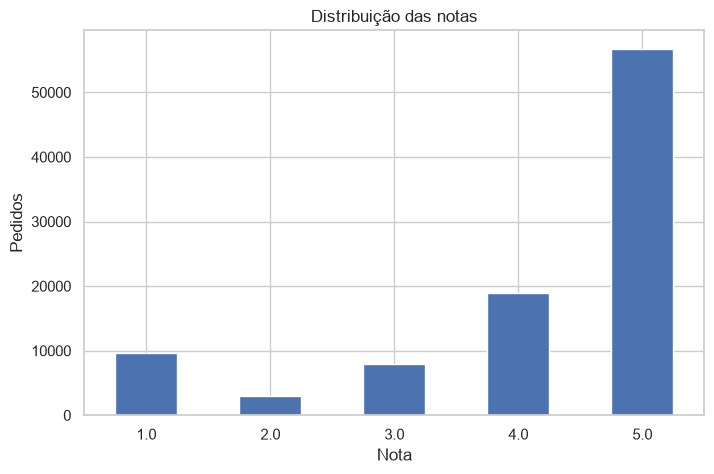

In [8]:
df.review_score.value_counts().sort_index().plot.bar(color="#4C72B0")
plt.title("Distribuição das notas"); plt.xlabel("Nota"); plt.ylabel("Pedidos"); plt.xticks(rotation=0); plt.show()

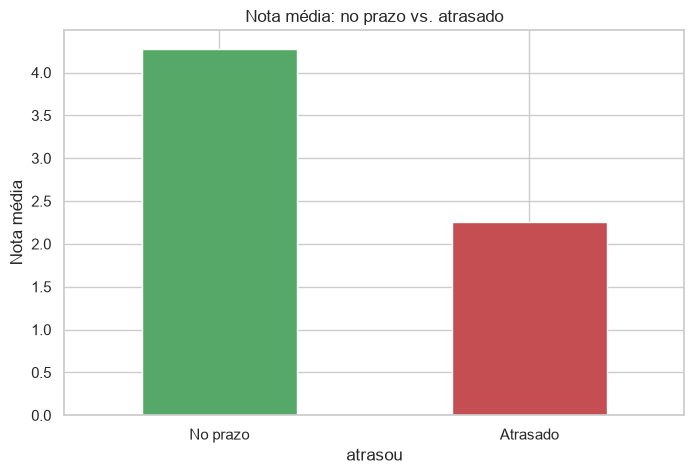

In [9]:
df.groupby("atrasou")["review_score"].mean().plot.bar(color=["#55A868","#C44E52"])
plt.title("Nota média: no prazo vs. atrasado"); plt.ylabel("Nota média")
plt.xticks([0,1],["No prazo","Atrasado"],rotation=0); plt.show()

C:\Users\gabri\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\gabri\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


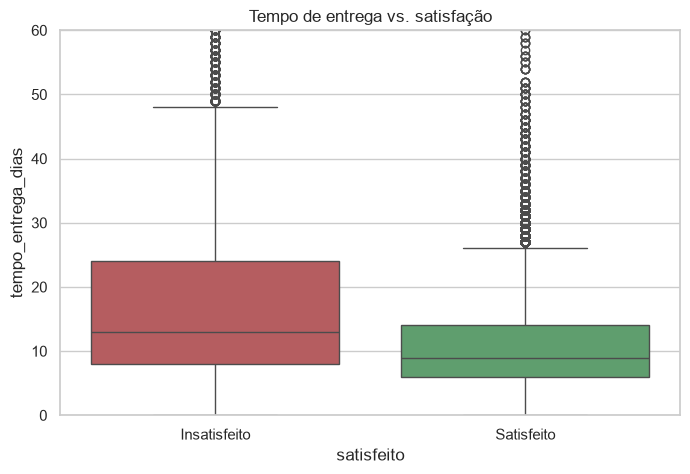

In [10]:
sns.boxplot(data=df, x="satisfeito", y="tempo_entrega_dias", palette=["#C44E52","#55A868"])
plt.title("Tempo de entrega vs. satisfação"); plt.xticks([0,1],["Insatisfeito","Satisfeito"]); plt.ylim(0,60); plt.show()

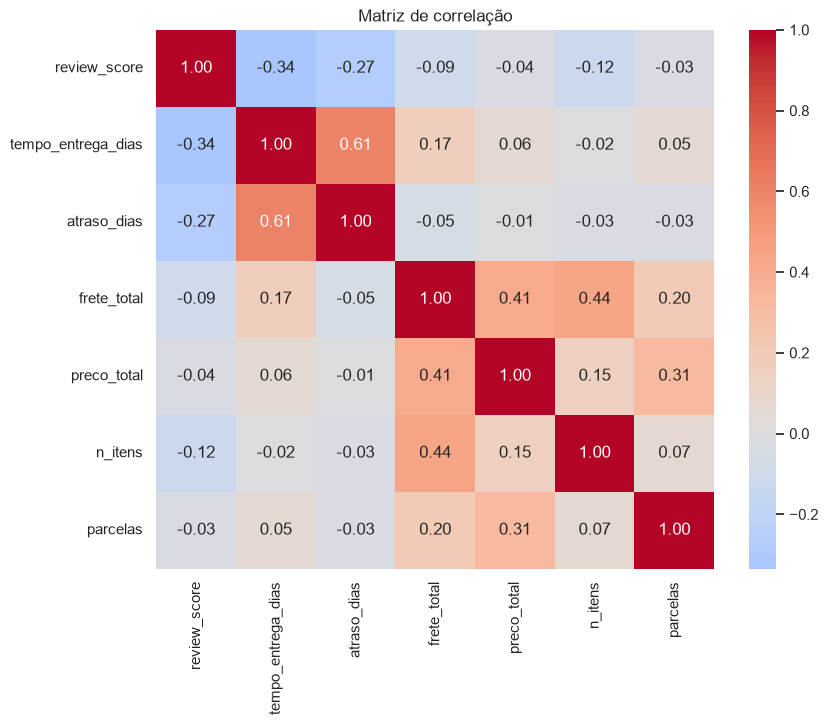

In [11]:
num=["review_score","tempo_entrega_dias","atraso_dias","frete_total","preco_total","n_itens","parcelas"]
plt.figure(figsize=(9,7)); sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação"); plt.show()

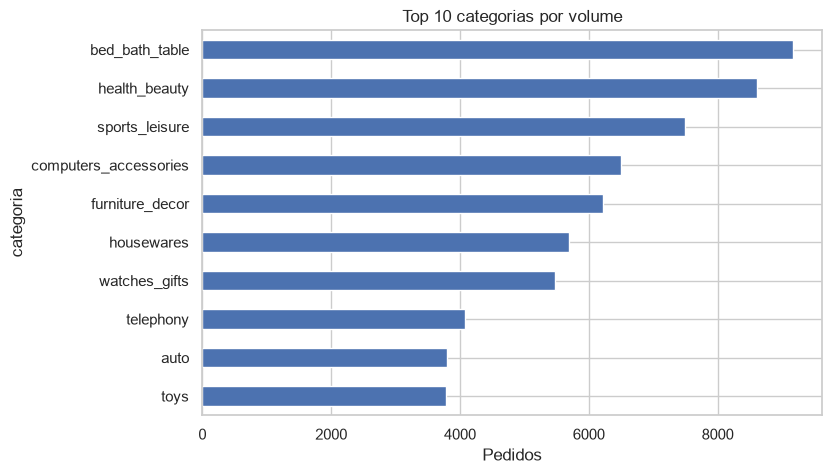

In [12]:
df.categoria.value_counts().head(10).sort_values().plot.barh(color="#4C72B0")
plt.title("Top 10 categorias por volume"); plt.xlabel("Pedidos"); plt.show()

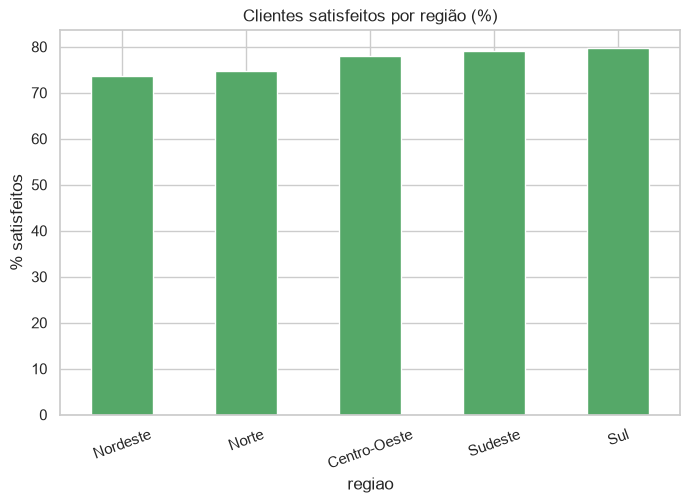

In [13]:
(df.groupby("regiao")["satisfeito"].mean()*100).sort_values().plot.bar(color="#55A868")
plt.title("Clientes satisfeitos por região (%)"); plt.ylabel("% satisfeitos"); plt.xticks(rotation=20); plt.show()

## 7 e 9. Modelagem Preditiva (Classificação) e Métricas
Prever se o cliente fica **satisfeito** (nota ≥ 4) com 3 modelos.

In [14]:
feats=["tempo_entrega_dias","atraso_dias","frete_total","preco_total","n_itens","parcelas"]
X=pd.DataFrame(StandardScaler().fit_transform(df[feats]),columns=feats); y=df.satisfeito
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
mods={"Regressao Logistica":LogisticRegression(max_iter=1000),
      "Arvore de Decisao":DecisionTreeClassifier(max_depth=5,random_state=42),
      "KNN (k=15)":KNeighborsClassifier(n_neighbors=15)}
res={}
for nome,m in mods.items():
    m.fit(Xtr,ytr); p=m.predict(Xte); pr=m.predict_proba(Xte)[:,1]
    res[nome]={"modelo":m,"pred":p,"proba":pr,"Acuracia":accuracy_score(yte,p),"Precisao":precision_score(yte,p),
               "Recall":recall_score(yte,p),"F1":f1_score(yte,p),"AUC":roc_auc_score(yte,pr)}
    print(f"{nome:22s} Ac={res[nome]['Acuracia']:.3f} F1={res[nome]['F1']:.3f} AUC={res[nome]['AUC']:.3f}")
melhor=max(res,key=lambda k:res[k]['F1'])
print("\n>>> Melhor:",melhor)
print(classification_report(yte,res[melhor]['pred'],target_names=["Insatisfeito","Satisfeito"]))

Regressao Logistica    Ac=0.811 F1=0.891 AUC=0.688
Arvore de Decisao      Ac=0.821 F1=0.897 AUC=0.694


KNN (k=15)             Ac=0.816 F1=0.893 AUC=0.669

>>> Melhor: Arvore de Decisao
              precision    recall  f1-score   support

Insatisfeito       0.81      0.22      0.35      5174
  Satisfeito       0.82      0.99      0.90     18944

    accuracy                           0.82     24118
   macro avg       0.81      0.60      0.62     24118
weighted avg       0.82      0.82      0.78     24118



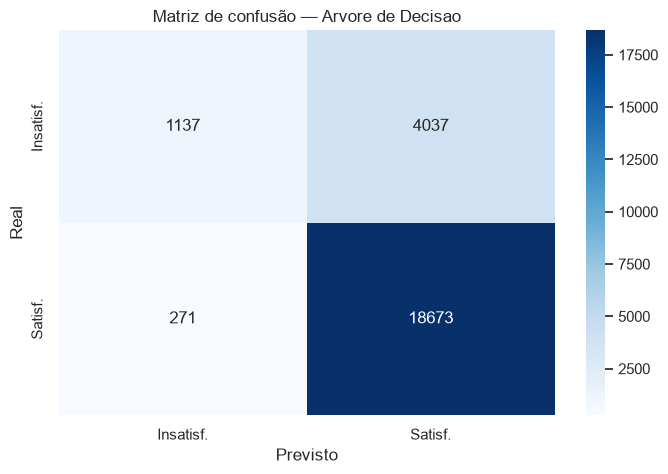

In [15]:
# Matriz de confusao
sns.heatmap(confusion_matrix(yte,res[melhor]['pred']),annot=True,fmt='d',cmap='Blues',
            xticklabels=["Insatisf.","Satisf."],yticklabels=["Insatisf.","Satisf."])
plt.title(f"Matriz de confusão — {melhor}"); plt.xlabel("Previsto"); plt.ylabel("Real"); plt.show()

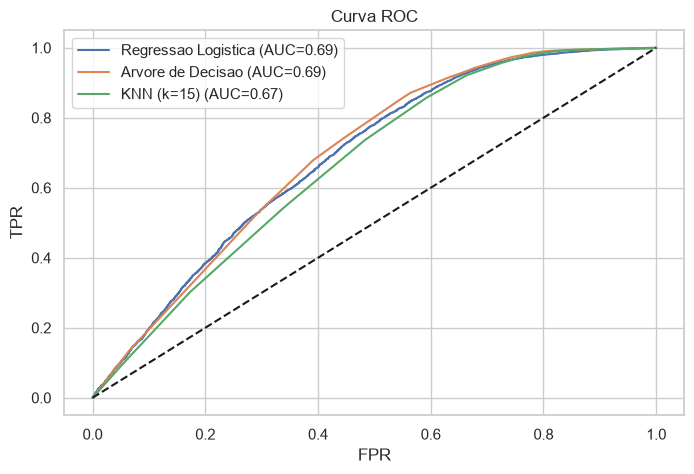

In [16]:
# Curva ROC
for nome in res:
    fpr,tpr,_=roc_curve(yte,res[nome]['proba']); plt.plot(fpr,tpr,label=f"{nome} (AUC={res[nome]['AUC']:.2f})")
plt.plot([0,1],[0,1],"k--"); plt.title("Curva ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

## 7. Regressão Linear — prever a nota (1–5)

R2=0.135  MAE=0.93


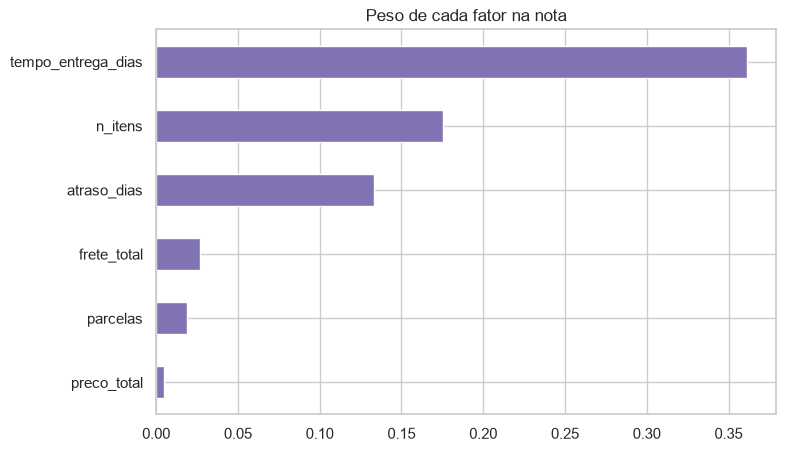

In [17]:
yr=df.review_score; Xr_tr,Xr_te,yr_tr,yr_te=train_test_split(X,yr,test_size=0.25,random_state=42)
reg=LinearRegression().fit(Xr_tr,yr_tr); yp=reg.predict(Xr_te)
print("R2=%.3f  MAE=%.2f" % (r2_score(yr_te,yp), mean_absolute_error(yr_te,yp)))
pd.Series(np.abs(reg.coef_),index=feats).sort_values().plot.barh(color="#8172B3")
plt.title("Peso de cada fator na nota"); plt.show()

## 8. Machine Learning — Segmentação de Clientes (K-Means / RFM)

Silhouette: 0.491


,Recencia,Frequencia,Monetario
cluster,,,
0,127.1,1.0,113.4
1,386.3,1.0,114.0
2,219.4,2.1,243.2
3,236.7,1.0,1142.0


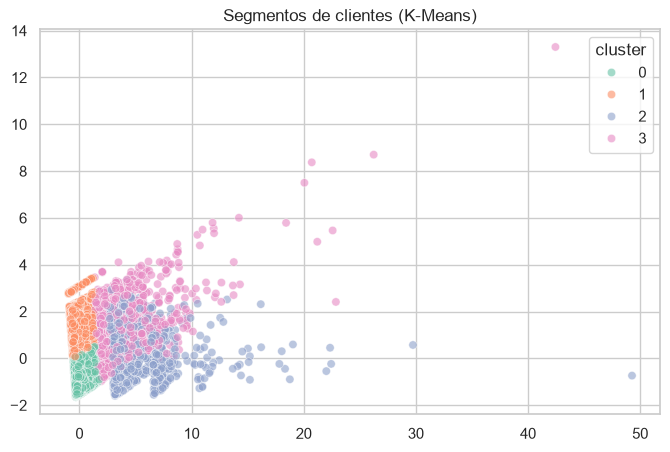

In [18]:
ref=df.order_purchase_timestamp.max()
rfm=df.groupby("customer_unique_id").agg(Recencia=("order_purchase_timestamp",lambda x:(ref-x.max()).days),
     Frequencia=("order_id","count"),Monetario=("preco_total","sum")).reset_index()
Xr=StandardScaler().fit_transform(rfm[["Recencia","Frequencia","Monetario"]])
rfm["cluster"]=KMeans(n_clusters=4,random_state=42,n_init=10).fit_predict(Xr)
print("Silhouette:",round(silhouette_score(Xr,rfm.cluster),3))
display(rfm.groupby("cluster")[["Recencia","Frequencia","Monetario"]].mean().round(1))
comp=PCA(n_components=2).fit_transform(Xr)
sns.scatterplot(x=comp[:,0],y=comp[:,1],hue=rfm.cluster,palette="Set2",alpha=0.6)
plt.title("Segmentos de clientes (K-Means)"); plt.show()

## 8. Machine Learning — Regras de Associação (Apriori)
Quais combinações de fatores levam à insatisfação.

In [19]:
it_a=pd.DataFrame({"Atrasou":df.atrasou==1,"Entrega_lenta":df.tempo_entrega_dias>df.tempo_entrega_dias.median(),
    "Frete_alto":df.frete_total>df.frete_total.median(),"Parcelado":df.parcelado==1,
    "Preco_alto":df.preco_total>df.preco_total.median(),"Insatisfeito":df.satisfeito==0})
fr=apriori(it_a,min_support=0.02,use_colnames=True)
rg=association_rules(fr,metric="confidence",min_threshold=0.35)
rg=rg[rg.consequents.astype(str).str.contains("Insatisfeito")].sort_values("lift",ascending=False)
display(rg[["antecedents","consequents","support","confidence","lift"]].head(6))

,antecedents,consequents,support,confidence,lift
103,"frozenset({Atrasou, Frete_alto})","frozenset({Insatisfeito, Entrega_lenta})",0.029699,0.756935,5.686534
116,"frozenset({Atrasou, Parcelado})","frozenset({Insatisfeito, Entrega_lenta})",0.026921,0.744766,5.595114
126,"frozenset({Atrasou, Preco_alto})","frozenset({Insatisfeito, Entrega_lenta})",0.026869,0.742693,5.579541
119,frozenset({Atrasou}),"frozenset({Insatisfeito, Entrega_lenta, Parcel...",0.026921,0.397520,5.505870
33,frozenset({Atrasou}),"frozenset({Insatisfeito, Entrega_lenta})",0.049011,0.723710,5.436930
127,frozenset({Atrasou}),"frozenset({Insatisfeito, Entrega_lenta, Preco_...",0.026869,0.396755,5.401433


## Conclusões e Limitações

**O que os dados mostraram**
- A entrega é decisiva: pedido atrasado tem nota média **2,26**, contra **4,28** no prazo.
- No prazo, **82%** ficam satisfeitos; atrasado, só **26%**.
- **Atraso + frete alto** disparam a insatisfação (regra com lift ~5,7).
- A maioria dos clientes compra uma única vez.

**Limitações**
- O modelo prevê bem os satisfeitos, mas erra a minoria insatisfeita (classes desbalanceadas).
- Os comentários escritos não foram usados (poderiam enriquecer com NLP).
- Dados de 2016–2018, de uma única loja (Olist).
